# NB01 - Regresión logística desde cero con Titanic

Este notebook reproduce el corazón matemático de la regresión logística: logit, odds, máxima verosimilitud, log-loss y descenso de gradiente. Usaremos la matriz procesada de Titanic creada en NB00.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

from src.titanic_utils import (
    RANDOM_STATE,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_sigmoid,
    set_plot_style,
)

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. El problema: la regresión lineal no es una probabilidad

Una regresión lineal puede producir valores menores que 0 o mayores que 1. Para clasificación binaria necesitamos una función que respete el rango probabilístico y que modele el efecto de las variables sobre los log-odds.


Predicción lineal mínima: -0.317
Predicción lineal máxima: 1.100


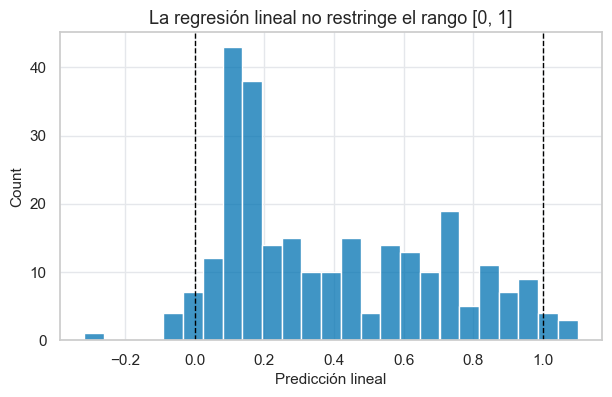

In [2]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_scores = linear_model.predict(X_test)

print(f"Predicción lineal mínima: {linear_scores.min():.3f}")
print(f"Predicción lineal máxima: {linear_scores.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(linear_scores, bins=25, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_title("La regresión lineal no restringe el rango [0, 1]")
ax.set_xlabel("Predicción lineal")
plt.show()


## 2. Sigmoide, odds y logit

La función logística transforma cualquier predictor lineal en una probabilidad. Si `p` es la probabilidad de sobrevivir, entonces `logit(p) = log(p / (1 - p))`. Un coeficiente positivo aumenta los log-odds de supervivencia; uno negativo los reduce.


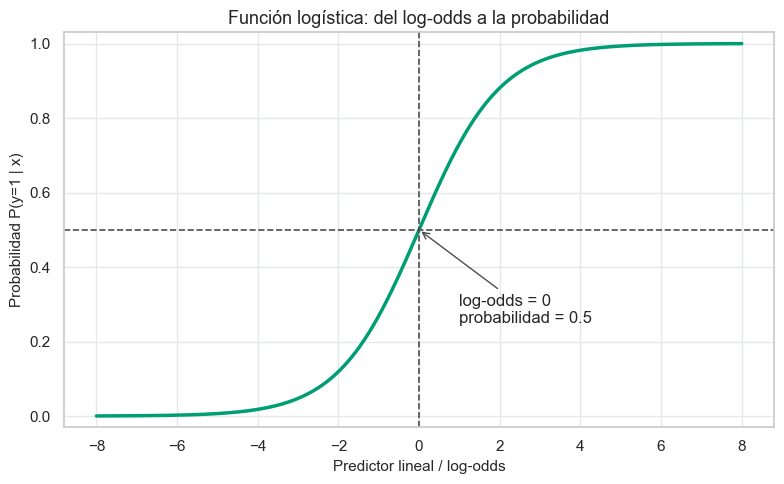

In [3]:
plot_sigmoid()
plt.show()


## 3. Modelo e interpretación

Con variables ya imputadas, codificadas y escaladas, el modelo es:

`P(survived=1 | x) = sigmoid(beta_0 + beta_1 x_1 + ... + beta_p x_p)`.

La interpretación causal no está garantizada: el Titanic es observacional. Los coeficientes describen asociaciones condicionales dentro del conjunto de variables seleccionado.


## 4. Máxima verosimilitud, log-loss y descenso de gradiente

Implementaremos descenso de gradiente con `learning_rate=0.1`, `n_iter=5000` y `tol=1e-8`. La tasa de aprendizaje es razonable porque las numéricas están estandarizadas; `n_iter` da margen de convergencia; `tol` detiene temprano cuando la pérdida deja de mejorar de forma material.


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -35, 35)))


def add_intercept(X):
    return np.c_[np.ones(X.shape[0]), np.asarray(X)]


def binary_log_loss(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


def fit_logistic_gradient_descent(X, y, learning_rate=0.1, n_iter=5000, tol=1e-8):
    X_design = add_intercept(X)
    y_array = np.asarray(y)
    beta = np.zeros(X_design.shape[1])
    losses = []

    previous_loss = np.inf
    for iteration in range(n_iter):
        probabilities = sigmoid(X_design @ beta)
        gradient = X_design.T @ (probabilities - y_array) / len(y_array)
        beta -= learning_rate * gradient
        current_loss = binary_log_loss(y_array, probabilities)
        losses.append(current_loss)
        if abs(previous_loss - current_loss) < tol:
            break
        previous_loss = current_loss

    return beta, np.array(losses)


beta_hat, losses = fit_logistic_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    n_iter=5000,
    tol=1e-8,
)

print(f"Iteraciones usadas: {len(losses)}")
print(f"Log-loss final en train: {losses[-1]:.4f}")


Iteraciones usadas: 4752
Log-loss final en train: 0.4336


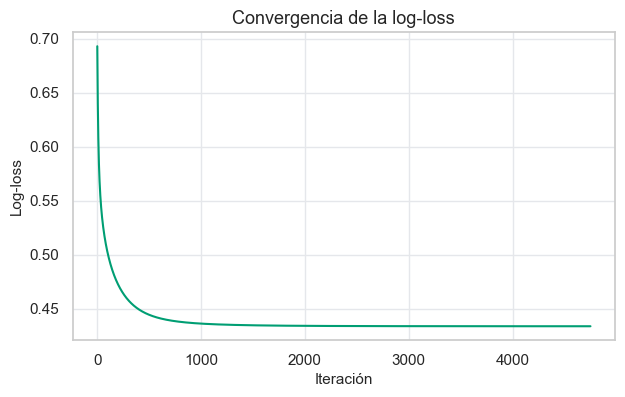

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color="#009E73")
ax.set_title("Convergencia de la log-loss")
ax.set_xlabel("Iteración")
ax.set_ylabel("Log-loss")
plt.show()


## 5. Comparación con scikit-learn

Para comparar contra máxima verosimilitud usamos `penalty=None`: no se añade regularización. `solver="lbfgs"` es adecuado para datasets pequeños y densos. `max_iter=1000` es un límite de seguridad para convergencia, no un hiperparámetro estadístico del modelo.


In [6]:
X_test_design = add_intercept(X_test)
manual_prob = sigmoid(X_test_design @ beta_hat)

sk_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=1000,
)
sk_model.fit(X_train, y_train)
sk_prob = sk_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame(
    {
        "modelo": ["desde_cero", "sklearn_sin_penalizacion"],
        "log_loss": [
            log_loss(y_test, manual_prob),
            log_loss(y_test, sk_prob),
        ],
        "auc": [
            roc_auc_score(y_test, manual_prob),
            roc_auc_score(y_test, sk_prob),
        ],
        "accuracy_umbral_0_5": [
            accuracy_score(y_test, manual_prob >= 0.5),
            accuracy_score(y_test, sk_prob >= 0.5),
        ],
    }
)
display(comparison)

coef_df = pd.DataFrame(
    {
        "feature": ["intercepto"] + feature_names,
        "desde_cero": beta_hat,
        "sklearn": np.r_[sk_model.intercept_, sk_model.coef_.ravel()],
    }
)
coef_df["diferencia_abs"] = (coef_df["desde_cero"] - coef_df["sklearn"]).abs()
display(coef_df.sort_values("diferencia_abs", ascending=False))


,modelo,log_loss,auc,accuracy_umbral_0_5
0,desde_cero,0.4456,0.8544,0.8022
1,sklearn_sin_penalizacion,0.4453,0.8550,0.8022


,feature,desde_cero,sklearn,diferencia_abs
0,intercepto,1.5905,1.6223,3.1856e-02
7,embarked_Q,0.4599,0.4292,3.0689e-02
9,alone_True,-0.6777,-0.6978,2.0056e-02
8,embarked_S,-0.2114,-0.2267,1.5318e-02
6,sex_male,-2.6373,-2.6450,7.6480e-03
3,sibsp,-0.5137,-0.5204,6.6560e-03
4,parch,-0.1702,-0.1755,5.3230e-03
5,fare,0.0880,0.0857,2.3842e-03
1,pclass,-0.9077,-0.9056,2.0868e-03
2,age,-0.5658,-0.5657,3.4997e-05


## 6. Frontera de decisión en 2D

La frontera se dibuja con `age` y `fare`, ambas estandarizadas por el preprocesador. Es una vista parcial: el modelo 2D ignora sexo, clase y embarque para que la superficie pueda visualizarse.


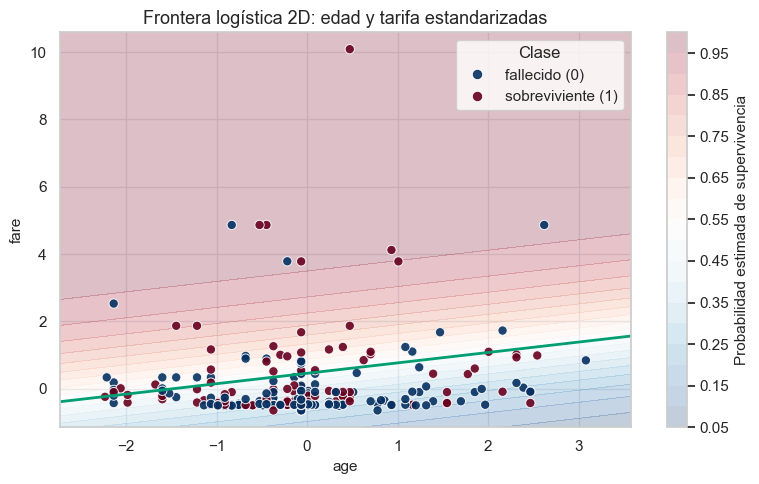

In [7]:
two_features = ["age", "fare"]
model_2d = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
model_2d.fit(X_train[two_features], y_train)

plot_decision_boundary(
    model_2d,
    X_test[two_features],
    y_test,
    two_features,
    "Frontera logística 2D: edad y tarifa estandarizadas",
)
plt.show()


## Resumen y conexión con la literatura

La regresión logística se ajusta por máxima verosimilitud, no por mínimos cuadrados ordinarios. El descenso de gradiente implementado aquí minimiza la log-loss, equivalente a maximizar la verosimilitud Bernoulli. Esta conexión es la base de Berkson, Cox, Agresti y Bishop.
